<a href="https://colab.research.google.com/github/rcsanju6887/TaxEstimator/blob/main/AI_Stress_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Install Kaggle
!pip install kaggle --quiet

In [ ]:
#  Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


sns.set(style="whitegrid", context="notebook")
pd.set_option('display.max_columns', 50)
print(" Libraries Imported Successfully!")

 Libraries Imported Successfully!


In [ ]:
#  Load Dataset
file_path = '/content/drive/MyDrive/Stress-Lysis.csv'
df = pd.read_csv(file_path)
print(" Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDataset Description:\n", df.describe())

 Dataset Shape: (2001, 4)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Humidity      2001 non-null   float64
 1   Temperature   2001 non-null   float64
 2   Step count    2001 non-null   int64  
 3   Stress Level  2001 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 62.7 KB
None

Missing Values:
 Humidity        0
Temperature     0
Step count      0
Stress Level    0
dtype: int64

Dataset Description:
           Humidity  Temperature   Step count  Stress Level
count  2001.000000  2001.000000  2001.000000   2001.000000
mean     20.000000    89.000000   100.141429      1.104448
std       5.777833     5.777833    58.182948      0.771094
min      10.000000    79.000000     0.000000      0.000000
25%      15.000000    84.000000    50.000000      0.000000
50%      20.000000    89.000000   101.000000      1.000000


EDA

/tmp/ipykernel_258/345235812.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Stress Level', palette='viridis')


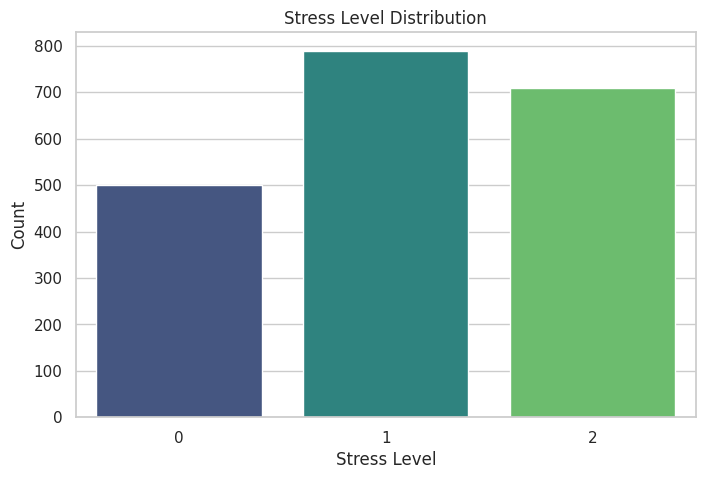

In [ ]:

# Stress Level Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Stress Level', palette='viridis')
plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Count")
plt.show()

<Figure size 1600x800 with 0 Axes>

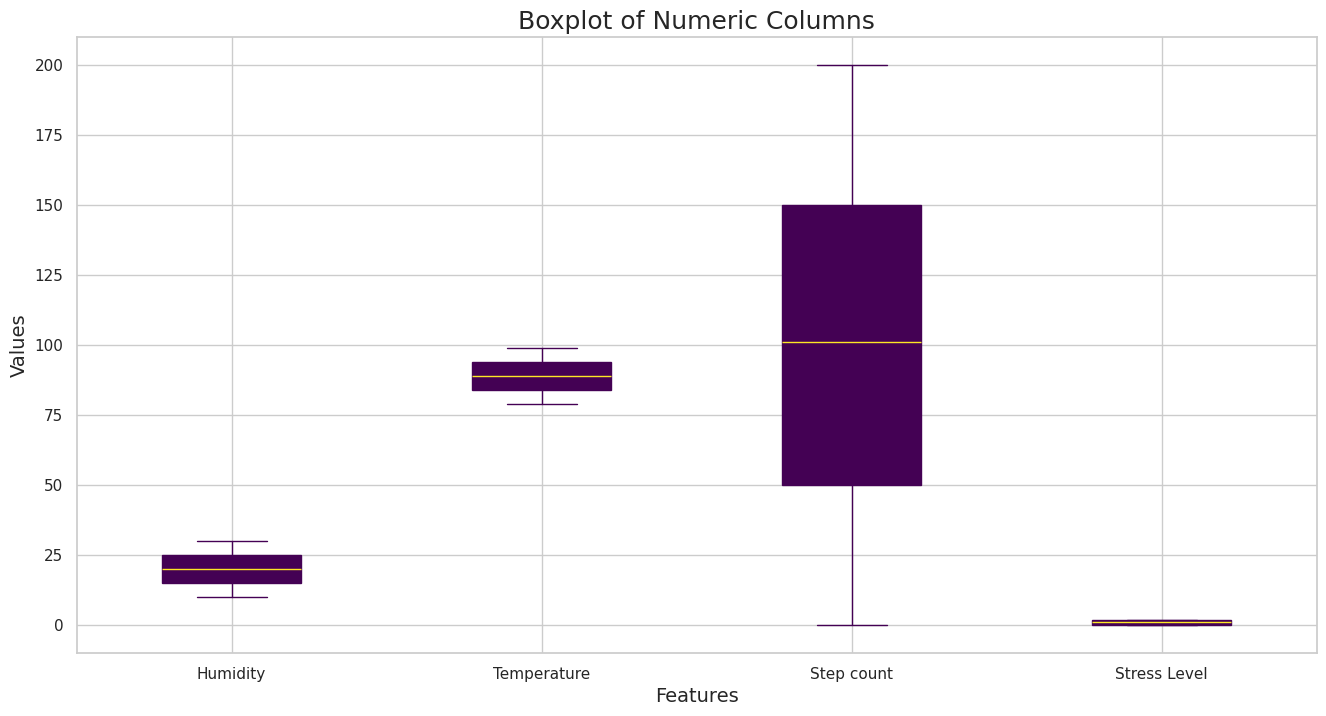


 OUTLIERS (IQR METHOD) 

Column: Humidity
Lower bound: 0.00, Upper bound: 40.00
No outliers

Column: Temperature
Lower bound: 69.00, Upper bound: 109.00
No outliers

Column: Step count
Lower bound: -100.00, Upper bound: 300.00
No outliers

Column: Stress Level
Lower bound: -3.00, Upper bound: 5.00
No outliers


In [ ]:
# Boxplot
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(16,8))
df[numeric_cols].plot(kind='box', figsize=(16,8), patch_artist=True, colormap='viridis')
plt.title("Boxplot of Numeric Columns", fontsize=18)
plt.xlabel("Features", fontsize=14)
plt.ylabel("Values", fontsize=14)
plt.show()

# Outlier Detection
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q2 = series.quantile(0.5)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

print("\n OUTLIERS (IQR METHOD) ")
for col in numeric_cols:
    out_vals, low, high = detect_outliers(df[col])
    print(f"\nColumn: {col}")
    print(f"Lower bound: {low:.2f}, Upper bound: {high:.2f}")
    print("Outliers:" if not out_vals.empty else "No outliers")
    if not out_vals.empty:
        print(out_vals.values)

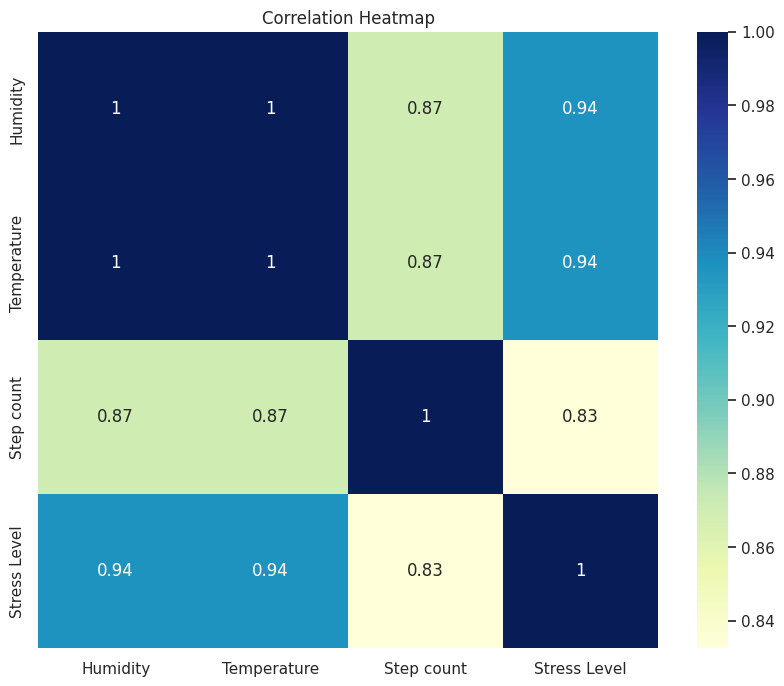

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('Stress Level', axis=1)
y = df['Stress Level']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 1600, Testing samples: 401


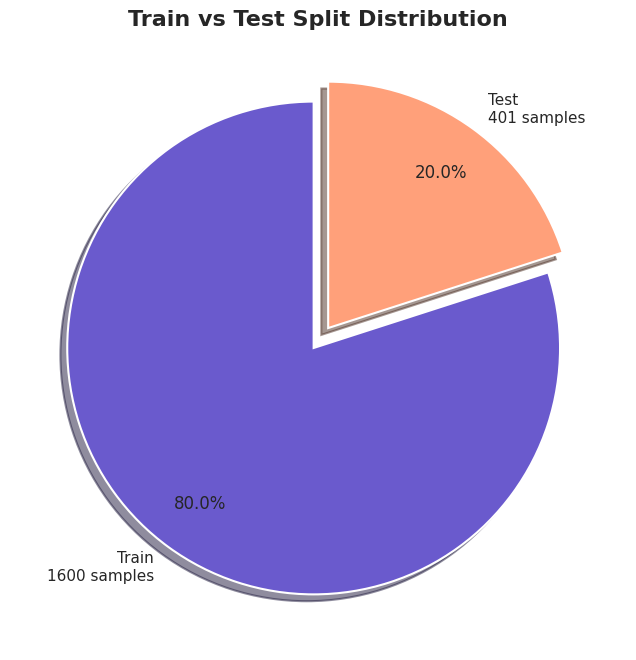

In [ ]:
#PiE CHART (Train vs Test Split)

train_size = len(X_train)
test_size = len(X_test)

sizes = [train_size, test_size]
labels = [
    f"Train\n{train_size} samples",
    f"Test\n{test_size} samples"
]

colors = ["#6a5acd", "#ffa07a"]

plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    explode=[0.03, 0.07],
    shadow=True,
    colors=colors,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)

plt.title("Train vs Test Split Distribution", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
#  Define Models
models = {
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [ ]:
# Cross-Validation for all models
from sklearn.model_selection import cross_val_score

print(" 5-Fold Cross-Validation for All Models ")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"\n{name} Cross-Validation Accuracy Scores: {cv_scores}")
    print(f"{name} Mean CV Accuracy: {cv_scores.mean():.4f}")

 5-Fold Cross-Validation for All Models 

KNN Cross-Validation Accuracy Scores: [1.     1.     0.9925 1.     1.    ]
KNN Mean CV Accuracy: 0.9985

SVM Cross-Validation Accuracy Scores: [0.99750623 1.         0.9925     1.         1.        ]
SVM Mean CV Accuracy: 0.9980

Random Forest Cross-Validation Accuracy Scores: [1.     1.     0.9975 0.9975 1.    ]
Random Forest Mean CV Accuracy: 0.9990

Logistic Regression Cross-Validation Accuracy Scores: [0.99750623 1.         0.9925     1.         0.9975    ]
Logistic Regression Mean CV Accuracy: 0.9975

Gradient Boosting Cross-Validation Accuracy Scores: [1. 1. 1. 1. 1.]
Gradient Boosting Mean CV Accuracy: 1.0000


In [ ]:
# Train All Models
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully!")

KNN trained successfully!
SVM trained successfully!
Random Forest trained successfully!
Logistic Regression trained successfully!
Gradient Boosting trained successfully!


In [ ]:
# Best Model
best_model = trained_models['Gradient Boosting']

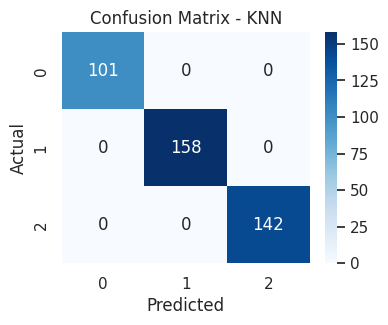

In [ ]:
#  Confusion Matrix - KNN
y_pred_knn = trained_models['KNN'].predict(X_test)
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(4,3))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

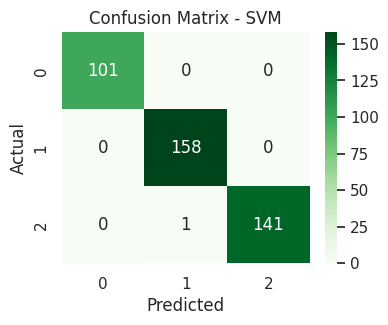

In [ ]:
y_pred_svm = trained_models['SVM'].predict(X_test)
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(4,3))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

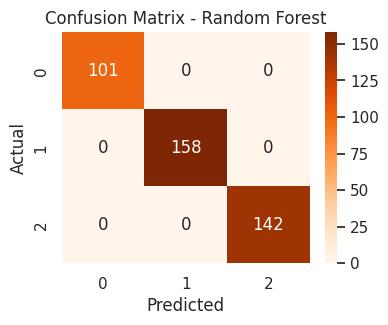

In [ ]:
# Confusion Matrix - Random Forest
y_pred_rf = trained_models['Random Forest'].predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

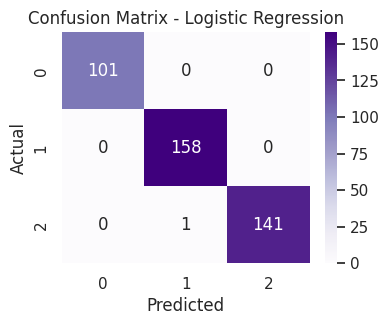

In [ ]:
# Confusion Matrix - Logistic Regression
y_pred_lr = trained_models['Logistic Regression'].predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(4,3))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

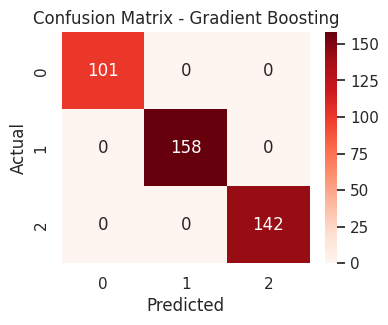

In [ ]:
# Confusion Matrix - Gradient Boosting
y_pred_gb = trained_models['Gradient Boosting'].predict(X_test)
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(4,3))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Light colors (pastel)
colors = ['#a6cee3','#b2df8a','#fb9a99','#cab2d6','#fdbf6f']

# Models
models_names = ['KNN', 'SVM', 'Random Forest', 'Logistic Regression', 'Gradient Boosting']

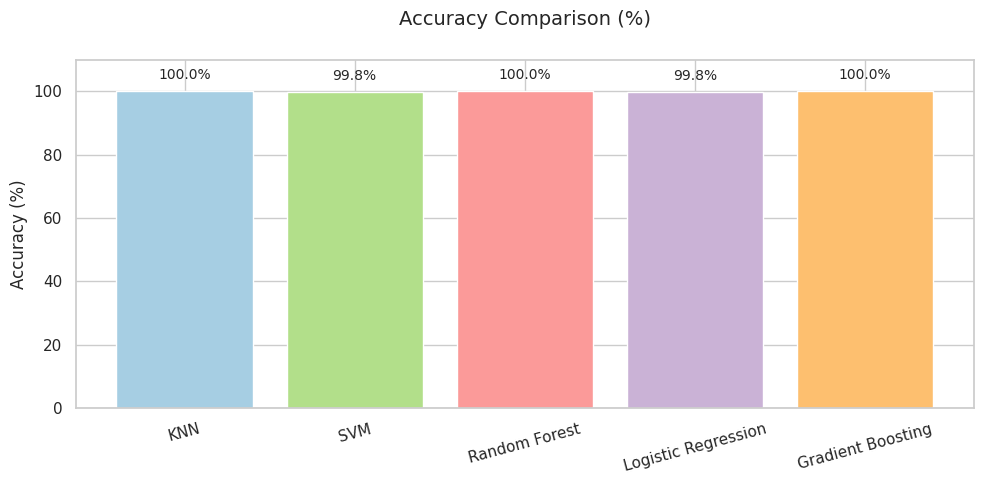

In [ ]:
acc_values = [
    accuracy_score(y_test, trained_models['KNN'].predict(X_test)) * 100,
    accuracy_score(y_test, trained_models['SVM'].predict(X_test)) * 100,
    accuracy_score(y_test, trained_models['Random Forest'].predict(X_test)) * 100,
    accuracy_score(y_test, trained_models['Logistic Regression'].predict(X_test)) * 100,
    accuracy_score(y_test, trained_models['Gradient Boosting'].predict(X_test)) * 100
]

# Accuracy Comparison
plt.figure(figsize=(10,5))

bars = plt.bar(models_names, acc_values, color=colors)
plt.ylim(0,110)
for i, v in enumerate(acc_values):
    plt.text(i, v + 3, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)  # label slightly higher
plt.title("Accuracy Comparison (%)", pad=25, fontsize=14)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

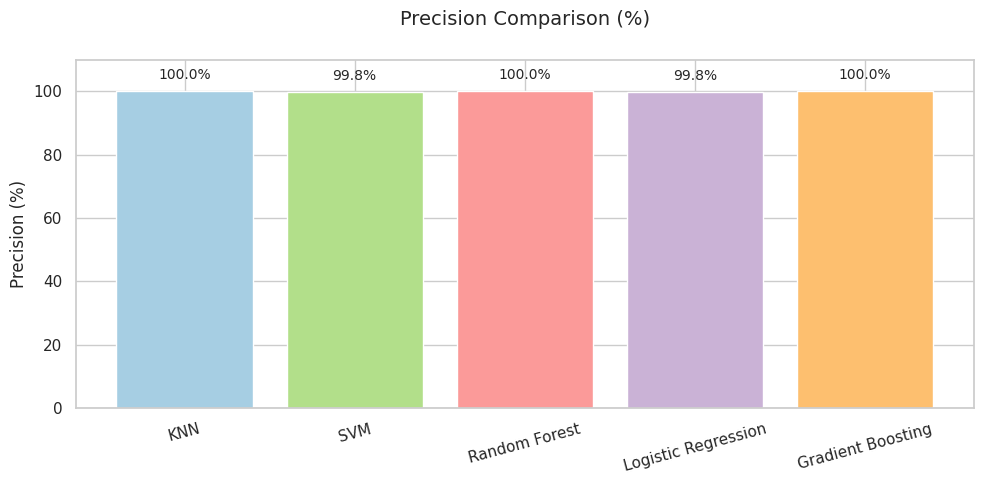

In [ ]:
# Precision Comparison
prec_values = [
    precision_score(y_test, trained_models['KNN'].predict(X_test), average='weighted') * 100,
    precision_score(y_test, trained_models['SVM'].predict(X_test), average='weighted') * 100,
    precision_score(y_test, trained_models['Random Forest'].predict(X_test), average='weighted') * 100,
    precision_score(y_test, trained_models['Logistic Regression'].predict(X_test), average='weighted') * 100,
    precision_score(y_test, trained_models['Gradient Boosting'].predict(X_test), average='weighted') * 100
]

plt.figure(figsize=(10,5))
bars = plt.bar(models_names, prec_values, color=colors)
plt.ylim(0,110)
for i, v in enumerate(prec_values):
    plt.text(i, v + 3, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)
plt.title("Precision Comparison (%)", pad=25, fontsize=14)
plt.ylabel("Precision (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

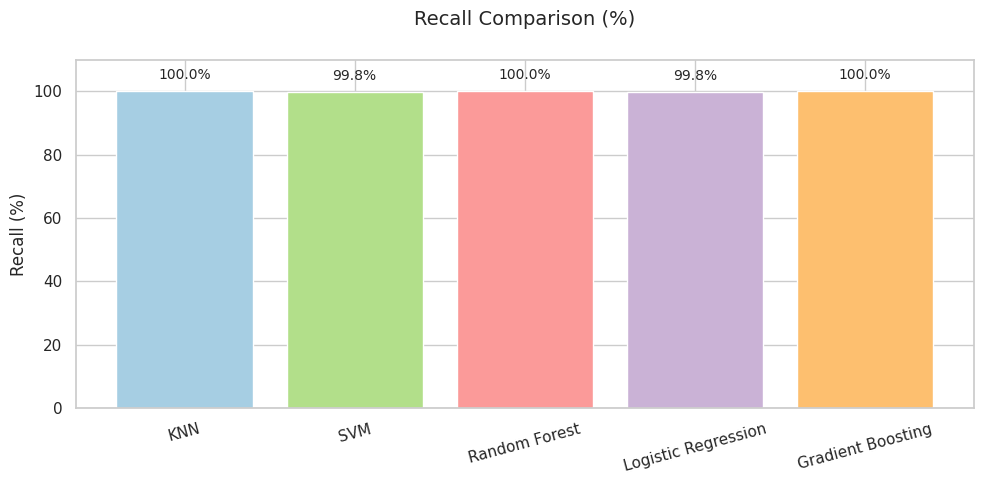

In [ ]:
# Recall Comparison
rec_values = [
    recall_score(y_test, trained_models['KNN'].predict(X_test), average='weighted') * 100,
    recall_score(y_test, trained_models['SVM'].predict(X_test), average='weighted') * 100,
    recall_score(y_test, trained_models['Random Forest'].predict(X_test), average='weighted') * 100,
    recall_score(y_test, trained_models['Logistic Regression'].predict(X_test), average='weighted') * 100,
    recall_score(y_test, trained_models['Gradient Boosting'].predict(X_test), average='weighted') * 100
]

plt.figure(figsize=(10,5))
bars = plt.bar(models_names, rec_values, color=colors)
plt.ylim(0,110)
for i, v in enumerate(rec_values):
    plt.text(i, v + 3, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)
plt.title("Recall Comparison (%)", pad=25, fontsize=14)
plt.ylabel("Recall (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

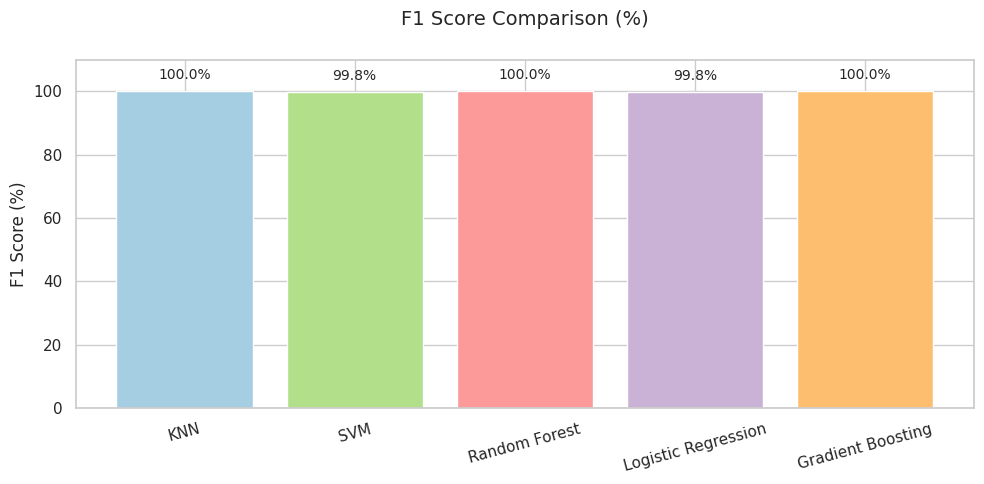

In [ ]:
# F1 Score Comparison
f1_values = [
    f1_score(y_test, trained_models['KNN'].predict(X_test), average='weighted') * 100,
    f1_score(y_test, trained_models['SVM'].predict(X_test), average='weighted') * 100,
    f1_score(y_test, trained_models['Random Forest'].predict(X_test), average='weighted') * 100,
    f1_score(y_test, trained_models['Logistic Regression'].predict(X_test), average='weighted') * 100,
    f1_score(y_test, trained_models['Gradient Boosting'].predict(X_test), average='weighted') * 100
]

plt.figure(figsize=(10,5))
bars = plt.bar(models_names, f1_values, color=colors)
plt.ylim(0,110)
for i, v in enumerate(f1_values):
    plt.text(i, v + 3, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)
plt.title("F1 Score Comparison (%)", pad=25, fontsize=14)
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_258/2323554566.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


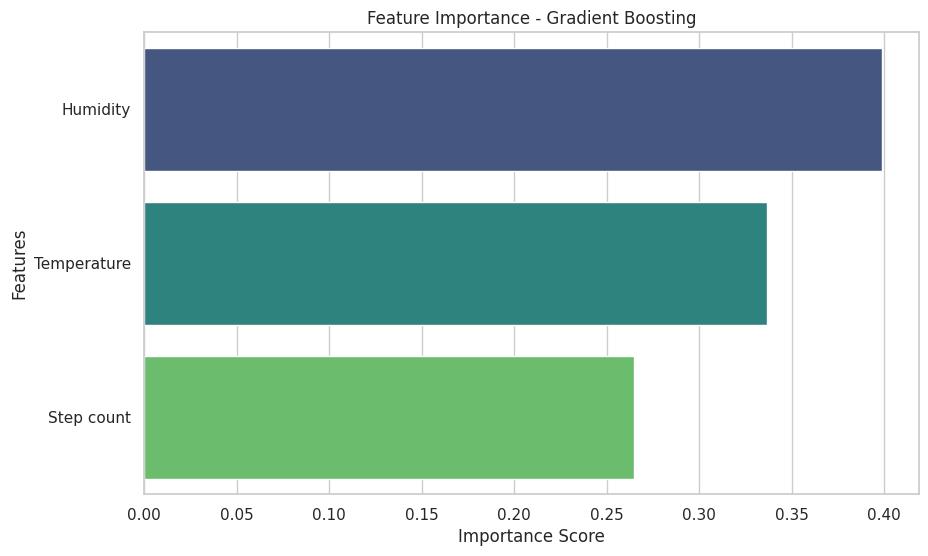

Top Features:
        Feature  Importance
0     Humidity    0.398772
1  Temperature    0.336458
2   Step count    0.264770


In [ ]:
feature_importances = best_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Feature Importance Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

print("Top Features:\n", feat_imp_df)

In [ ]:
# Feature Selection based on threshold
threshold = 0.05
selected_features = feat_imp_df[feat_imp_df['Importance'] >= threshold]['Feature'].tolist()
print("\nSelected Features for retraining:", selected_features)

# Retrain Gradient Boosting with selected features
X_selected = X[selected_features]
X_selected_scaled = scaler.fit_transform(X_selected)

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
best_model_sel = GradientBoostingClassifier(random_state=42)
best_model_sel.fit(X_train_sel, y_train_sel)
y_pred_sel = best_model_sel.predict(X_test_sel)
print("\nAccuracy after Feature Selection:", accuracy_score(y_test_sel, y_pred_sel))


Selected Features for retraining: ['Humidity', 'Temperature', 'Step count']

Accuracy after Feature Selection: 1.0


Test


In [ ]:

# UI SECTION (FINAL & CLEAN)


from IPython.display import display, HTML
import ipywidgets as widgets
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Stress-Lysis.csv')

# Features
X = df[['Humidity', 'Temperature', 'Step count']]
y = df['Stress Level']

# Fit scaler on ALL DATA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train best model on full dataset
best_model = GradientBoostingClassifier()
best_model.fit(X_scaled, y)


display(HTML("""
<div style="background-color:#f7f7f7; padding:20px; border-radius:10px; text-align:center;">
    <h2 style="color:#1d3557; font-family:Arial;"> Stress Level Prediction</h2>
    <p style="color:#1d3557; font-family:Arial; font-size:16px;">Enter the values below to calculate your stress level</p>
</div>
"""))

# Create inputs
inputs = {}
for feature in X.columns:
    inputs[feature] = widgets.FloatText(
        value=0.0,
        layout=widgets.Layout(width='300px', height='40px'),
        description=f'{feature}:',
        style={'description_width': '150px'}
    )

# Align input boxes
input_boxes = [
    widgets.HBox([widgets.Label(' ' * 2), w], layout=widgets.Layout(justify_content='center', padding='5px'))
    for w in inputs.values()
]

# Predict button
predict_btn = widgets.Button(
    description='Predict Stress Level',
    layout=widgets.Layout(width='320px', height='45px', margin='20px auto'),
    style={'button_color': '#8b0000', 'font_weight': 'bold'}
)

output_box = widgets.Output()

# Prediction function
def on_predict_clicked(b):
    with output_box:
        output_box.clear_output()

        user_input = {f: inputs[f].value for f in X.columns}
        input_df = pd.DataFrame([user_input])


        input_scaled = scaler.transform(input_df)

        pred = best_model.predict(input_scaled)[0]

        display(HTML(f"""
        <div style="
            border: 2px solid #1d3557;
            background-color: #ffffff;
            padding: 25px;
            border-radius: 15px;
            width: 50%;
            margin: 20px auto;
            text-align: center;
            font-family: Arial;
            font-size: 20px;
            font-weight: bold;
            color: #1d3557;
            box-shadow: 2px 2px 12px rgba(0,0,0,0.15);
        ">
        Predicted Stress Level: <span style="color:#e63946;">{pred}</span>
        </div>
        """))

predict_btn.on_click(on_predict_clicked)


form = widgets.VBox(input_boxes + [predict_btn, output_box], layout=widgets.Layout(align_items='center'))
display(form)